# KAN Vision Transformer for Skin Lesion Classification

## 1. Setup and Imports

In [1]:
%pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 3.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'repr' attribute with value.*")
warnings.filterwarnings("ignore", message=".*The 'frozen' attribute with value.*")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchinfo import summary
import timm
from kan import KAN
from tqdm import tqdm
import copy

import random
import numpy as np
import os

def seed_everything(seed=42):
    """Seed Python, NumPy, and torch RNGs for reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed_everything()

import cv2
from PIL import Image


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedxc4/skin-ds")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/skin-ds


## 2. KAN ViT Implementation

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class KANLinear(nn.Module):
    """Linear layer with learnable B-spline activations on each edge."""
    def __init__(
        self,
        in_features,
        out_features,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        enable_standalone_scale_spline=True,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        """Build the layers."""
        super(KANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (
                torch.arange(-spline_order, grid_size + spline_order + 1) * h
                + grid_range[0]
            )
            .expand(in_features, -1)
            .contiguous()
        )
        self.register_buffer("grid", grid)

        self.base_weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        if enable_standalone_scale_spline:
            self.spline_scaler = nn.Parameter(
                torch.Tensor(out_features, in_features)
            )

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        self.grid_eps = grid_eps

        self.reset_parameters()

    def reset_parameters(self):
        """Initialize the base and spline weights."""
        torch.nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (
                (
                    torch.rand(self.grid_size + 1, self.in_features, self.out_features)
                    - 1 / 2
                )
                * self.scale_noise
                / self.grid_size
            )
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(
                    self.grid.T[self.spline_order : -self.spline_order],
                    noise,
                )
            )
            if self.enable_standalone_scale_spline:
                torch.nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x: torch.Tensor):
        """
        Compute the B-spline bases for the given input tensor.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).

        Returns:
            torch.Tensor: B-spline bases tensor of shape (batch_size, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features

        grid: torch.Tensor = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)])
                / (grid[:, k:-1] - grid[:, : -(k + 1)])
                * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x)
                / (grid[:, k + 1 :] - grid[:, 1:(-k)])
                * bases[:, :, 1:]
            )

        assert bases.size() == (
            x.size(0),
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return bases

    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        """
        Compute the coefficients of the curve that interpolates the given points.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).
            y (torch.Tensor): Output tensor of shape (batch_size, in_features, out_features).

        Returns:
            torch.Tensor: Coefficients tensor of shape (out_features, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features
        assert y.size() == (x.size(0), self.in_features, self.out_features)

        A = self.b_splines(x).transpose(0, 1)  # (in_features, batch_size, grid_size + spline_order)
        B = y.transpose(0, 1)  # (in_features, batch_size, out_features)
        solution = torch.linalg.lstsq(
            A, B
        ).solution  # (in_features, grid_size + spline_order, out_features)
        result = solution.permute(
            2, 0, 1
        )  # (out_features, in_features, grid_size + spline_order)

        assert result.size() == (
            self.out_features,
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return result

    @property
    def scaled_spline_weight(self):
        """Return spline weights scaled by per-edge standardization."""
        return self.spline_weight * (
            self.spline_scaler.unsqueeze(-1)
            if self.enable_standalone_scale_spline
            else 1.0
        )

    def forward(self, x: torch.Tensor):
        """Run the forward pass."""
        assert x.dim() == 2 and x.size(1) == self.in_features

        base_output = F.linear(self.base_activation(x), self.base_weight)
        
        # Efficient implementation of spline computation
        x_norm = (x - self.grid[0, 0]) / (self.grid[0, -1] - self.grid[0, 0]) * 2 - 1
        # Clamp to avoid out of range
        x_norm = torch.clamp(x_norm, -1 + self.grid_eps, 1 - self.grid_eps)
        
        spline_output = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )
        return base_output + spline_output


class EfficientKAN(nn.Module):
    """Stack of KANLinear layers used as a transformer feedforward."""
    def __init__(
        self,
        layers_hidden,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        """Build the layers."""
        super(EfficientKAN, self).__init__()
        self.layers = nn.ModuleList()
        for in_features, out_features in zip(layers_hidden, layers_hidden[1:]):
            self.layers.append(
                KANLinear(
                    in_features,
                    out_features,
                    grid_size=grid_size,
                    spline_order=spline_order,
                    scale_noise=scale_noise,
                    scale_base=scale_base,
                    scale_spline=scale_spline,
                    base_activation=base_activation,
                    grid_eps=grid_eps,
                    grid_range=grid_range,
                )
            )

    def forward(self, x: torch.Tensor, update_grid=False):
        """Run the forward pass."""
        for layer in self.layers:
            if update_grid:
                pass
            x = layer(x)
        return x



In [ ]:
class KANViTBlock(nn.Module):
    """Transformer block with self-attention and a KAN or MLP feedforward."""
    def __init__(
        self,
        dim,
        num_heads,
        mlp_ratio=4.0,
        qkv_bias=False,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        act_layer=nn.GELU,
        norm_layer=nn.LayerNorm,
        use_kan=True
    ):
        """Build the layers."""
        super().__init__()

        # Robust import for timm versions
        try:
            from timm.layers import DropPath, Mlp, Attention
        except ImportError:
            from timm.models.layers import DropPath, Mlp
            from timm.models.vision_transformer import Attention

        self.norm1 = norm_layer(dim)
        
        # Use Attention from layers if available, else standard
        self.attn = Attention(
            dim,
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            attn_drop=attn_drop,
            proj_drop=drop
        )

        self.drop_path = (
            DropPath(drop_path)
            if drop_path > 0.0 else nn.Identity()
        )

        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)

        if use_kan:
            self.mlp = EfficientKAN(
                layers_hidden=[dim, mlp_hidden_dim, dim],
                grid_size=5,
                spline_order=3
            )
        else:
            self.mlp = Mlp(
                in_features=dim,
                hidden_features=mlp_hidden_dim,
                act_layer=act_layer,
                drop=drop
            )

    def forward(self, x):
        """Run the forward pass."""
        x = x + self.drop_path(self.attn(self.norm1(x)))

        # Reshape for KAN (Batch, Tokens, Dim) -> (Batch * Tokens, Dim)
        B, N, C = x.shape
        x_reshaped = self.norm2(x).reshape(-1, C)
        x_kan = self.mlp(x_reshaped)
        x_kan = x_kan.reshape(B, N, C)

        x = x + self.drop_path(x_kan)
        return x

## 3. Model Creation

In [6]:
class EfficientKANViT(nn.Module):
    """EfficientNet backbone feeding KAN-ViT blocks and a linear head."""
    def __init__(self, num_classes, embed_dim=384, depth=4, num_heads=8, mlp_ratio=3.0, input_size=224):
        """Build the layers."""
        super().__init__()
        # 1. Feature Extractor (EfficientNet-B3 for High Accuracy)
        print("Initializing EfficientNet-B3 backbone...")
        self.backbone = timm.create_model('efficientnet_b3', pretrained=True, features_only=True)
        
        # Freeze backbone weights
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # 2. Dynamic Channel Detection
        # To avoid hardcoding 320 or 384, we run a dummy pass
        with torch.no_grad():
            dummy = torch.zeros(1, 3, input_size, input_size)
            features = self.backbone(dummy)[-1]
            in_channels = features.shape[1]
            feat_map_size = features.shape[2]
            print(f"Backbone Output: {in_channels} channels, {feat_map_size}x{feat_map_size} map")
            
        # 3. Projection Layer
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=1)
        
        # Calculate number of tokens
        self.num_tokens = feat_map_size * feat_map_size
        
        # 4. Transformer Encoder (KAN-ViT)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens, embed_dim))
        self.pos_drop = nn.Dropout(p=0.0)
        
        # Stack KANViTBlocks
        self.blocks = nn.ModuleList([
            KANViTBlock(
                dim=embed_dim, 
                num_heads=num_heads, 
                mlp_ratio=mlp_ratio,
                use_kan=(i % 2 == 0)
            ) for i in range(depth)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        
        # 5. Classification Head
        self.head = nn.Linear(embed_dim, num_classes)
        
        self._init_weights()

    def _init_weights(self):
        """Initialize positional embedding and head weights."""
        nn.init.trunc_normal_(self.pos_embed, std=.02)
        nn.init.xavier_uniform_(self.head.weight)
        if self.head.bias is not None:
            nn.init.constant_(self.head.bias, 0)

    def forward(self, x):
        # x: (B, 3, H, W)
        """Run the forward pass."""
        features = self.backbone(x)[-1] 
        x = self.proj(features) 
        x = x.flatten(2).transpose(1, 2) 
        x = x + self.pos_embed
        x = self.pos_drop(x)
        
        for block in self.blocks:
            x = block(x)
            
        x = self.norm(x)
        x = x.mean(dim=1) 
        x = self.head(x) 
        return x

def create_kan_vit(num_classes=7, embed_dim=384, depth=4, num_heads=8, mlp_ratio=3.0):
    """Build an EfficientKANViT with the given depth, width, and heads."""
    model = EfficientKANViT(
        num_classes=num_classes, 
        embed_dim=embed_dim, 
        depth=depth, 
        num_heads=num_heads,
        mlp_ratio=mlp_ratio,
        input_size=224 # Upgrade default to 224
    )
    return model

# Create the model
num_classes = 14
kan_vit_model = create_kan_vit(num_classes=num_classes, embed_dim=384, depth=4, num_heads=8, mlp_ratio=3.0)

# Print model summary with new input size
summary(kan_vit_model, input_size=(1, 3, 224, 224))


Initializing EfficientNet-B3 backbone...


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone Output: 384 channels, 7x7 map


Layer (type:depth-idx)                             Output Shape              Param #
EfficientKANViT                                    [1, 14]                   18,816
├─EfficientNetFeatures: 1-1                        [1, 24, 112, 112]         --
│    └─Conv2d: 2-1                                 [1, 40, 112, 112]         (1,080)
│    └─BatchNormAct2d: 2-2                         [1, 40, 112, 112]         80
│    │    └─Identity: 3-1                          [1, 40, 112, 112]         --
│    │    └─SiLU: 3-2                              [1, 40, 112, 112]         --
│    └─Sequential: 2-3                             --                        --
│    │    └─Sequential: 3-3                        [1, 24, 112, 112]         (3,504)
│    │    └─Sequential: 3-4                        [1, 32, 56, 56]           (48,118)
│    │    └─Sequential: 3-5                        [1, 48, 28, 28]           (110,912)
│    │    └─Sequential: 3-6                        [1, 96, 14, 14]           (638,700)
│

## 4. Data Loading and Preprocessing

In [7]:

# OFFLINE PREPROCESSING (Run Once)
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

class HairRemoval:
    """Removes hair from a lesion image with a BLACKHAT mask and inpainting."""
    def __init__(self, kernel_size=17):
        """Build the layers."""
        self.kernel_size = kernel_size
    def __call__(self, img):
        """Apply the transform to one image."""
        img_np = np.array(img)
        # Check RGB
        if len(img_np.shape) == 3:
            gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        else:
            gray = img_np
        # BlackHat
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (self.kernel_size, self.kernel_size))
        blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
        # Threshold
        _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
        # Inpaint
        result = cv2.inpaint(img_np, mask, 1, cv2.INPAINT_TELEA)
        return Image.fromarray(result)

def preprocess_dataset(src_dir, dst_dir):
    """Apply hair removal to every image and write the processed dataset."""
    if os.path.exists(dst_dir):
        print(f"Dataset already processed at {dst_dir}")
        return

    print(f"Preprocessing {src_dir} -> {dst_dir}")
    remover = HairRemoval()
    
    # Try to create dir (May fail in read-only Kaggle input, warning user)
    try:
        os.makedirs(dst_dir, exist_ok=True)
    except OSError:
        print("Warning: Could not create directory at /kaggle/input/. Check permissions or change path")
        return

    for phase in ['train', 'val']:
        phase_src = os.path.join(src_dir, phase)
        phase_dst = os.path.join(dst_dir, phase)
        if not os.path.exists(phase_src): continue

        for class_name in os.listdir(phase_src):
            class_src = os.path.join(phase_src, class_name)
            class_dst = os.path.join(phase_dst, class_name)
            os.makedirs(class_dst, exist_ok=True)

            if not os.path.isdir(class_src): continue

            for fname in tqdm(os.listdir(class_src), desc=f"{phase}/{class_name}"):
                if not fname.lower().endswith(('.jpg', '.jpeg', '.png')): continue
                
                src_path = os.path.join(class_src, fname)
                dst_path = os.path.join(class_dst, fname)
                
                try:
                    img = cv2.imread(src_path)
                    if img is None: continue
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Process in RGB
                    cleaned = remover(img)
                    # Convert back to BGR for cv2 save
                    cleaned_bgr = cv2.cvtColor(np.array(cleaned), cv2.COLOR_RGB2BGR)
                    cv2.imwrite(dst_path, cleaned_bgr)
                except Exception as e:
                    print(f"Error {src_path}: {e}")

# Run Preprocessing
# Note: In Kaggle Kernels, input is read-only. You may need to change output to /kaggle/working/
RAW_DATA_DIR = '/kaggle/input/skin-ds/'
PROCESSED_DATA_DIR = '/kaggle/working/skin-ds-processed/' 
preprocess_dataset(RAW_DATA_DIR, PROCESSED_DATA_DIR)


Preprocessing /kaggle/input/skin-ds/ -> /kaggle/working/skin-ds-processed/


val/Cowpox: 100%|██████████| 99/99 [00:02<00:00, 44.47it/s] 


In [9]:

from collections import Counter
from torch.utils.data import WeightedRandomSampler
import torch

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Upgraded to 224
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),   # Resize larger then crop
        transforms.CenterCrop(224), # Upgraded to 224
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
}

data_dir = '/kaggle/working/skin-ds-processed/'

image_datasets = {
    x: datasets.ImageFolder(
        root=f"{data_dir}/{x}",
        transform=data_transforms[x]
    )
    for x in ['train', 'val']
}

# --- WEIGHTED SAMPLING IMPLEMENTATION ---
# Get train labels
train_labels = [label for _, label in image_datasets['train'].samples]
class_counts = Counter(train_labels)

# Compute weights
class_weights = []
for i in range(len(image_datasets['train'].classes)):
    class_weights.append(1.0 / class_counts[i])
    
class_weights = torch.tensor(class_weights, dtype=torch.float)
sample_weights = [class_weights[label] for _, label in image_datasets['train'].samples]

generator = torch.Generator()
generator.manual_seed(42)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=generator
)

dataloaders = {
    'train': DataLoader(
        image_datasets['train'],
        batch_size=32,
        shuffle=False, # Must be False when using sampler
        sampler=sampler,
        num_workers=4,
        pin_memory=True
    ),
    'val': DataLoader(
        image_datasets['val'],
        batch_size=32,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print("Classes:", class_names)
print("Number of classes:", len(class_names))
print("Training size:", dataset_sizes['train'])
print("Validation size:", dataset_sizes['val'])


# For training set
train_counts = Counter(train_labels)

# For validation set
val_labels = [label for _, label in image_datasets['val'].samples]
val_counts = Counter(val_labels)

# Print nicely
print("=" * 60)
print(f"{'Class':<35} {'Train':>10} {'Val':>10}")
print("=" * 60)

for idx, class_name in enumerate(class_names):
    print(f"{class_name:<35} {train_counts[idx]:>10} {val_counts[idx]:>10}")

print("=" * 60)
print(f"{'TOTAL':<35} {len(image_datasets['train']):>10} {len(image_datasets['val']):>10}")



Classes: ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions', 'Chickenpox', 'Cowpox', 'Dermatofibroma', 'HFMD', 'Healthy', 'Measles', 'Melanocytic nevi', 'Melanoma', 'Monkeypox', 'Squamous cell carcinoma', 'Vascular lesions']
Number of classes: 14
Training size: 29322
Validation size: 3660
Class                                    Train        Val
Actinic keratoses                          693         86
Basal cell carcinoma                      2658        332
Benign keratosis-like lesions             2099        262
Chickenpox                                 900        112
Cowpox                                     792         99
Dermatofibroma                             191         23
HFMD                                      1932        241
Healthy                                   1368        171
Measles                                    660         82
Melanocytic nevi                         10300       1287
Melanoma                                  361

## 5. Training the Model

In [10]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, LinearLR, SequentialLR
import csv
import copy
import math
import os

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = kan_vit_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

scheduler_warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=3)
scheduler_main = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_main], milestones=[3])

num_epochs = 25

def train_model(model, criterion, optimizer, num_epochs, scheduler=None, reset_log=True):
    """Train the model, log per-epoch metrics, and keep the best checkpoint."""
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    scaler = torch.cuda.amp.GradScaler()
    
    csv_file = 'training_history.csv'
    header = ['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'learning_rates']
    
    # LOGGING SETUP
    import os
    mode = 'w' if reset_log else 'a'
    should_write_header = reset_log or not os.path.exists(csv_file)
    
    if should_write_header:
        with open(csv_file, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(header)
        print(f"Created new training log: {csv_file}")
    else:
        print(f"Appending to existing training log: {csv_file}")

    for epoch in range(num_epochs):
        print(f"Epoch {epoch}/{num_epochs - 1}")
        print("-" * 10)
        
        metrics = {}

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0
            loss_nans = 0

            for inputs, labels in tqdm(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    if phase == 'train':
                        if device.type == 'cuda':
                            with torch.cuda.amp.autocast():
                                outputs = model(inputs)
                                loss = criterion(outputs, labels)
                        else:
                            outputs = model(inputs)
                            loss = criterion(outputs, labels)
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    if torch.isnan(loss):
                        loss_nans += 1
                        continue
                        
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.unscale_(optimizer)
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        scaler.step(optimizer)
                        scaler.update()
                
                loss_val = loss.item()
                if not math.isnan(loss_val):
                    running_loss += loss_val * inputs.size(0)
                    running_corrects += (preds == labels).sum().item()
            
            if phase == 'train' and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            metrics[phase] = (epoch_loss, epoch_acc)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
            if loss_nans > 0:
                print(f"Warning: {loss_nans} batches skipped due to NaN loss in {phase}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        
        current_lrs = [group['lr'] for group in optimizer.param_groups]
        
        with open(csv_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch, 
                metrics['train'][0], metrics['train'][1], 
                metrics['val'][0], metrics['val'][1],
                str(current_lrs)
            ])
                
        print(f"Current Learning Rates: {current_lrs}")

    print(f"Best val Acc: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model
# Start Training (Resets Log)
model_ft = train_model(model, criterion, optimizer, num_epochs, scheduler=scheduler, reset_log=True)

/tmp/ipykernel_101/3999550043.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Created new training log: training_history.csv
Epoch 0/24
----------


  0%|          | 0/917 [00:00<?, ?it/s]/tmp/ipykernel_101/3999550043.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 917/917 [03:22<00:00,  4.53it/s]


train Loss: 2.5430 Acc: 0.1509


100%|██████████| 115/115 [00:18<00:00,  6.17it/s]


...

val Loss: 0.8621 Acc: 0.6710
Current Learning Rates: [7.938926261462366e-05]
Epoch 24/24
----------


100%|██████████| 917/917 [03:09<00:00,  4.85it/s]


train Loss: 0.5415 Acc: 0.7989


100%|██████████| 115/115 [00:18<00:00,  6.35it/s]

val Loss: 0.8406 Acc: 0.6850
Current Learning Rates: [7.269952498697734e-05]
Best val Acc: 0.6850


In [11]:
model_ft = train_model(model, criterion, optimizer, num_epochs=25, scheduler=scheduler)

# Save the model
torch.save(model_ft.state_dict(), 'efficientnetb3_kan_vit_skin_lesion_25_epochs.pth')
print('model saved')

/tmp/ipykernel_101/3999550043.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Created new training log: training_history.csv
Epoch 0/24
----------


  0%|          | 0/917 [00:00<?, ?it/s]/tmp/ipykernel_101/3999550043.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 917/917 [03:09<00:00,  4.85it/s]


train Loss: 0.5274 Acc: 0.8040


100%|██████████| 115/115 [00:18<00:00,  6.38it/s]


...

val Loss: 0.8151 Acc: 0.6943
Current Learning Rates: [8.247240241650919e-05]
Epoch 24/24
----------


100%|██████████| 917/917 [03:09<00:00,  4.85it/s]


train Loss: 0.4085 Acc: 0.8468


100%|██████████| 115/115 [00:18<00:00,  6.37it/s]


val Loss: 0.8020 Acc: 0.7161
Current Learning Rates: [7.938926261462366e-05]
Best val Acc: 0.7161
model saved


## 6. Fine Tuning

In [12]:
# Load weights
try:
    model.load_state_dict(torch.load('/kaggle/working/efficientnetb3_kan_vit_skin_lesion_25_epochs.pth'))
    print("Loaded weights from local file.")
except FileNotFoundError:
    print("Could not find local weights. Proceeding with current model state...")

print("Unfreezing last 3 blocks of EfficientNet backbone...")
for name, param in model.backbone.named_parameters():
    if "blocks.4" in name or "blocks.5" in name or "blocks.6" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

backbone_params = []
head_params = []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if "backbone" in name:
        backbone_params.append(param)
    else:
        head_params.append(param)

optimizer_ft = optim.AdamW([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params, 'lr': 1e-4}
], weight_decay=1e-2)

scheduler_warmup = LinearLR(optimizer_ft, start_factor=0.01, end_factor=1.0, total_iters=5)
scheduler_main = CosineAnnealingWarmRestarts(optimizer_ft, T_0=5, T_mult=2)
scheduler_ft = SequentialLR(optimizer_ft, schedulers=[scheduler_warmup, scheduler_main], milestones=[5])

print("Starting Fine-tuning (Appends to Log)...")

def train_model(model, criterion, optimizer, num_epochs, scheduler=None, reset_log=True):
    """Train the model, log per-epoch metrics, and keep the best checkpoint."""
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    scaler = torch.cuda.amp.GradScaler()
    
    csv_file = 'training_history.csv'
    header = ['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'learning_rates']
    
    # LOGGING SETUP
    import os
    mode = 'w' if reset_log else 'a'
    should_write_header = reset_log or not os.path.exists(csv_file)
    
    if should_write_header:
        with open(csv_file, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(header)
        print(f"Created new training log: {csv_file}")
    else:
        print(f"Appending to existing training log: {csv_file}")

    for epoch in range(num_epochs):
        print(f"Epoch {epoch}/{num_epochs - 1}")
        print("-" * 10)
        
        metrics = {}

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0
            loss_nans = 0

            for inputs, labels in tqdm(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    if phase == 'train':
                        if device.type == 'cuda':
                            with torch.cuda.amp.autocast():
                                outputs = model(inputs)
                                loss = criterion(outputs, labels)
                        else:
                            outputs = model(inputs)
                            loss = criterion(outputs, labels)
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    if torch.isnan(loss):
                        loss_nans += 1
                        continue
                        
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.unscale_(optimizer)
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        scaler.step(optimizer)
                        scaler.update()
                
                loss_val = loss.item()
                if not math.isnan(loss_val):
                    running_loss += loss_val * inputs.size(0)
                    running_corrects += (preds == labels).sum().item()
            
            if phase == 'train' and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            metrics[phase] = (epoch_loss, epoch_acc)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
            if loss_nans > 0:
                print(f"Warning: {loss_nans} batches skipped due to NaN loss in {phase}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        
        current_lrs = [group['lr'] for group in optimizer.param_groups]
        
        with open(csv_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch, 
                metrics['train'][0], metrics['train'][1], 
                metrics['val'][0], metrics['val'][1],
                str(current_lrs)
            ])
                
        print(f"Current Learning Rates: {current_lrs}")

    print(f"Best val Acc: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model
# Continue Training (Appends to Log)
model_ft = train_model(model, criterion, optimizer_ft, num_epochs=25, scheduler=scheduler_ft, reset_log=False)

torch.save(model_ft.state_dict(), 'efficientnetb3_kan_vit_skin_lesion_50_epochs.pth')
print('Fine-tuned model saved.')

/tmp/ipykernel_101/1977705864.py:40: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Loaded weights from local file.
Unfreezing last 3 blocks of EfficientNet backbone...
Starting Fine-tuning (Appends to Log)...
Appending to existing training log: training_history.csv
Epoch 0/24
----------


  0%|          | 0/917 [00:00<?, ?it/s]/tmp/ipykernel_101/1977705864.py:80: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 917/917 [04:15<00:00,  3.58it/s]


train Loss: 0.3887 Acc: 0.8553


100%|██████████| 115/115 [00:18<00:00,  6.34it/s]


...

val Loss: 0.6432 Acc: 0.7915
Current Learning Rates: [9.045084971874738e-06, 9.045084971874738e-05]
Epoch 24/24
----------


100%|██████████| 917/917 [03:42<00:00,  4.12it/s]


train Loss: 0.1888 Acc: 0.9306


100%|██████████| 115/115 [00:18<00:00,  6.36it/s]


val Loss: 0.6776 Acc: 0.7847
Current Learning Rates: [8.535533905932739e-06, 8.535533905932738e-05]
Best val Acc: 0.7915
Fine-tuned model saved.


## 7. Evaluation & Visualization

Generating predictions for Confusion Matrix...


100%|██████████| 115/115 [00:19<00:00,  5.90it/s]


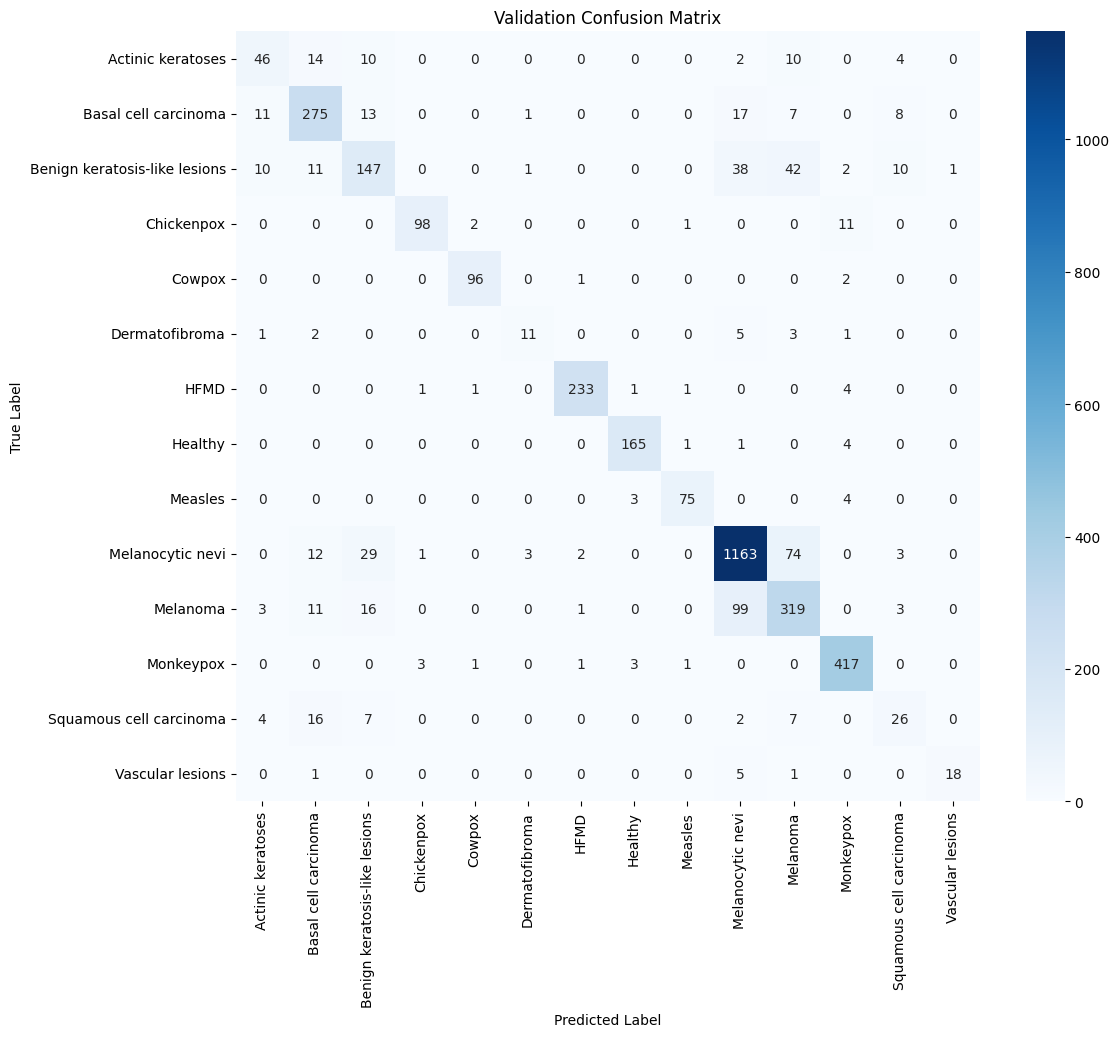

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Set model to evaluation mode
model.eval()

y_true = []
y_pred = []

print("Generating predictions for Confusion Matrix...")
with torch.no_grad():
    for inputs, labels in tqdm(dataloaders['val']):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Validation Confusion Matrix')
plt.show()

In [ ]:
# Test Time Augmentation (TTA) Evaluation

import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Define TTA Function
def evaluate_with_tta(model, dataloader, device):
    """Evaluate the model with test-time augmentation."""
    model.eval()
    all_preds = []
    all_labels = []
    
    print("Running Inference with Test Time Augmentation (TTA)...")
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # 1. Original Prediction
            outputs_orig = model(inputs)
            probs_orig = F.softmax(outputs_orig, dim=1)
            
            # 2. Horizontal Flip
            inputs_hflip = torch.flip(inputs, dims=[3]) 
            outputs_hflip = model(inputs_hflip)
            probs_hflip = F.softmax(outputs_hflip, dim=1)
            
            # 3. Vertical Flip
            inputs_vflip = torch.flip(inputs, dims=[2]) 
            outputs_vflip = model(inputs_vflip)
            probs_vflip = F.softmax(outputs_vflip, dim=1)
            
            # Average Probabilities
            avg_probs = (probs_orig + probs_hflip + probs_vflip) / 3.0
            
            _, preds = torch.max(avg_probs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    
    print(f"\nTTA Accuracy: {acc:.4f}")
    return acc, cm, all_preds, all_labels

# Load Model from Disk
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Re-create the model architecture 
# (Ensure these parameters match your training config)
loaded_model = create_kan_vit(
    num_classes=14, 
    embed_dim=384, 
    depth=4, 
    num_heads=8, 
    mlp_ratio=3.0
)

# Path to best saved model
checkpoint_path = 'kaggle/working/efficientnetb3_kan_vit_skin_lesion_50_epochs.pth' 
if os.path.exists(checkpoint_path):
    print(f"Loading weights from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Handle dictionary vs direct state_dict save
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        loaded_model.load_state_dict(checkpoint['model_state_dict'])
    else:
        loaded_model.load_state_dict(checkpoint)
        
    print("Model loaded successfully!")
else:
    print(f"Checkpoint {checkpoint_path} not found. Please check the path.")
loaded_model = loaded_model.to(device)

# Evaluate Imported Model
tta_acc, tta_cm, tta_preds, tta_labels = evaluate_with_tta(loaded_model, dataloaders['val'], device)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(tta_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'TTA Confusion Matrix (Acc: {tta_acc:.4f})')
plt.show()

### when downloading models from sidebar doesn't work

In [13]:
import os
import shutil
from IPython.display import FileLink, display

# Change to the working directory to ensure correct zipping
os.chdir(r'/kaggle/working')

# 1. Define paths - Save the zip in /kaggle/tmp to avoid recursion
zip_name = '/kaggle/tmp/zipped_output' # shutil adds .zip automatically
source_dir = '/kaggle/working'

# 2. Create the zip archive
# This zips everything in /kaggle/working but saves the result in /kaggle/tmp
shutil.make_archive(zip_name, 'zip', source_dir)

# 3. Move the final zip back to /kaggle/working so it is downloadable
final_path = '/kaggle/working/zipped_output.zip'
shutil.move(f'{zip_name}.zip', final_path)

# 4. Display download link
display(FileLink('zipped_output.zip'))

/kaggle/working/zipped_output.zip

In [14]:
# Define the file path
file_path = '/kaggle/working/zipped_output.zip'

# Check if it exists before trying to delete
if os.path.exists(file_path):
    os.remove(file_path)
    print(f"Successfully deleted {file_path}")
else:
    print("File not found.")


Successfully deleted /kaggle/working/zipped_output.zip
